#  Trader Behavior vs Market Sentiment Analysis

## Objective
The goal of this analysis is to explore the relationship between Bitcoin market sentiment (Fear vs Greed) and trader performance using historical trading data.

We aim to:
- Understand how sentiment affects profitability
- Identify behavioral patterns in trading
- Compare retail vs top traders
- Detect consistency in trading performance

##  Methodology

- Cleaned and standardized datasets  
- Corrected timestamp inconsistencies and aligned time formats  
- Performed time-series alignment using `merge_asof` to ensure accurate sentiment mapping  
- Segmented traders into retail vs top performers  
- Applied statistical and behavioral analysis across sentiment regimes  

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

## Data Cleaning & Preprocessing

In [3]:
# Cleaning column names
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

# Fixing timestamps
trades['timestamp'] = pd.to_datetime(trades['timestamp ist'], dayfirst=True)
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s', errors='coerce')

# Cleaning sentiment labels
def clean_sentiment(x):
    x = str(x).lower()
    if 'fear' in x:
        return 'fear'
    elif 'greed' in x:
        return 'greed'
    else:
        return 'neutral'

sentiment['classification'] = sentiment['classification'].apply(clean_sentiment)

# Sorting for merge
sentiment = sentiment.sort_values('timestamp')
trades = trades.sort_values('timestamp')

## Merge Datasets

In [4]:
df = pd.merge_asof(
    trades,
    sentiment[['timestamp', 'classification']],
    on='timestamp',
    direction='backward'
)

# Clean numeric columns
df['closed pnl'] = pd.to_numeric(df['closed pnl'], errors='coerce')
df['size usd'] = pd.to_numeric(df['size usd'], errors='coerce')

## Basic Exploration

In [5]:
df['classification'].value_counts()

classification
greed      88848
fear       82813
neutral    39563
Name: count, dtype: int64

## Core Analysis

### Profitability by Sentiment

In [6]:
df.groupby('classification')['closed pnl'].mean()

classification
fear       47.581299
greed      56.890240
neutral    32.910163
Name: closed pnl, dtype: float64

##### Traders achieve higher average profitability during Greed phases compared to Fear, indicating stronger returns in bullish market conditions.

### Win Rate

In [7]:
df['win'] = df['closed pnl'] > 0
df.groupby('classification')['win'].mean()

classification
fear       0.419946
greed      0.424883
neutral    0.362510
Name: win, dtype: float64

##### Win rates are slightly higher during Greed periods, suggesting marginally better trade success despite increased market optimism.

### Risk Behavior

In [8]:
df.groupby('classification')['size usd'].mean()

classification
fear       7278.747773
greed      4464.600019
neutral    4846.490928
Name: size usd, dtype: float64

##### Traders take significantly larger position sizes during Fear phases, indicating higher capital deployment under uncertain market conditions.

### Long vs Short

In [9]:
df.groupby(['classification', 'side']).size()

classification  side
fear            BUY     39254
                SELL    43559
greed           BUY     42310
                SELL    46538
neutral         BUY     21132
                SELL    18431
dtype: int64

##### Trading activity shows a balanced mix of long and short positions across sentiments, with a slight inclination toward short trades during Fear and Greed phases.

### Smart Money vs Retail

In [10]:
trader_perf = df.groupby('account')['closed pnl'].sum()
threshold = trader_perf.quantile(0.9)

df['trader_type'] = df['account'].apply(
    lambda x: 'top_trader' if trader_perf[x] >= threshold else 'retail'
)

df.groupby(['trader_type', 'classification'])['closed pnl'].mean()

trader_type  classification
retail       fear               29.111277
             greed              35.554574
             neutral            16.063950
top_trader   fear               84.274212
             greed             192.270121
             neutral            70.896259
Name: closed pnl, dtype: float64

##### Top traders significantly outperform retail traders across all market conditions, with especially strong gains during Greed phases, highlighting superior strategy and market timing.

### Consistency Analysis

In [11]:
trader_stats = df.groupby('account')['closed pnl'].agg(['mean', 'std'])
trader_stats = trader_stats[trader_stats['std'] > 0]

trader_stats['consistency_score'] = trader_stats['mean'] / trader_stats['std']

top_consistent = trader_stats.sort_values('consistency_score', ascending=False).head(10)
top_consistent

,mean,std,consistency_score
account,,,
0xae5eacaf9c6b9111fd53034a602c192a04e082ed,120.507317,474.809837,0.253801
0x6d6a4b953f202f8df5bed40692e7fd865318264a,111.519197,468.995982,0.237783
0x420ab45e0bd8863569a5efbb9c05d91f40624641,520.902331,2228.336140,0.233763
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,38.319560,172.520773,0.222116
0x430f09841d65beb3f27765503d0f850b8bce7713,336.735548,1649.497580,0.204144
0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,255.829091,0.203538
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d,41.474096,220.387735,0.188187
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,155.589314,855.354003,0.181900
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0,174.691809,976.068751,0.178975


##### Top consistent traders achieve stable returns with controlled variability, indicating disciplined strategies and effective risk management rather than reliance on sporadic high gains.

### Correlation Heatmap

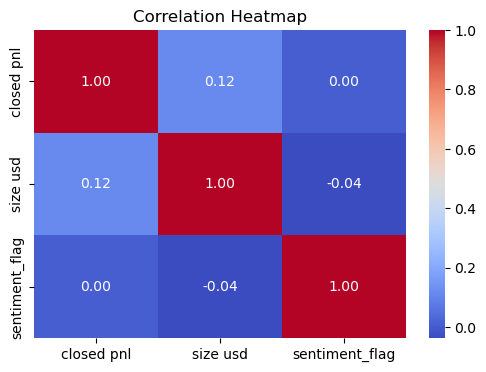

In [12]:
df['sentiment_flag'] = df['classification'].map({'fear': 0, 'greed': 1})

corr_df = df[['closed pnl', 'size usd', 'sentiment_flag']].dropna()

plt.figure(figsize=(6,4))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

##### Correlation analysis shows a weak relationship between sentiment, position size, and profitability, indicating that market sentiment influences trading behavior more than actual trading outcomes.

### Visualization

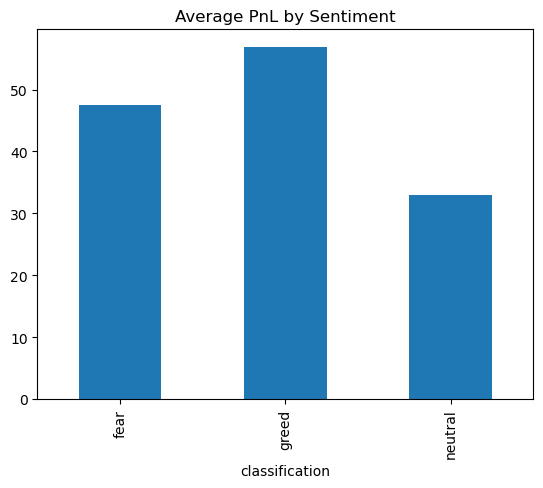

In [13]:
df.groupby('classification')['closed pnl'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.show()

##### The bar chart clearly shows that average profitability peaks during Greed phases, reinforcing the trend of higher returns in bullish market conditions compared to Fear and Neutral periods.

##  Key Findings

1. Traders achieve higher average profitability during Greed phases, indicating stronger returns in bullish market conditions.

2. Win rates are slightly higher during Greed periods, suggesting marginally better trade success despite increased market optimism.

3. Traders deploy larger position sizes during Fear phases, reflecting higher capital allocation under uncertain market conditions.

4. Trading behavior shows a relatively balanced mix of long and short positions, with a slight inclination toward short trades in Fear and Greed phases.

5. Top traders significantly outperform retail traders across all market conditions, with exceptional gains during Greed, highlighting superior strategy and execution.

6. Consistent traders demonstrate stable returns with lower variability, emphasizing the importance of disciplined risk management over sporadic high profits.

7. Correlation analysis indicates weak relationships between sentiment, position size, and profitability, suggesting that sentiment influences behavior more than actual outcomes.

8. Overall, while Greed drives higher profitability and activity, it does not guarantee better efficiency, and successful trading is largely driven by strategy, consistency, and risk control.

##  Strategy Recommendations

1. Traders should avoid aggressive position sizing during Greed phases, as higher risk does not consistently translate into higher returns.

2. Adopting disciplined strategies similar to top traders can significantly improve performance, especially in bullish markets.

3. Consistency should be prioritized over high-risk, high-reward trades, as stable traders outperform in the long run.

4. During Fear phases, traders can capitalize on more stable market conditions with controlled risk exposure.

5. Monitoring market sentiment can help traders adjust risk-taking behavior and avoid emotionally driven decisions.